# Library

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

root = Path.cwd()
root = root.parent.parent
data_path = root / "eval_results" / "model_comparison.csv"
df = pd.read_csv(data_path)
df.head(2)

,model_name,provider,model_id,scenario_id,scenario_category,task_type,valid_json,schema_pass,required_fields_present,must_include_pass,...,input_tokens,output_tokens,estimated_cost,specificity_score,tone_score,faithfullness_score,linkedin_readiness_score,refinement_quality_score,overall_quality_score,notes
0,openrouter_gpt_4o_mini,openrouter,openai/gpt-4o-mini,scenario_only_required_fields,required_only,generate,True,True,False,True,...,679.0,250.0,0.000252,4.5,4.5,5.0,4.8,4.3,4.62,NaN
1,openrouter_gpt_4o_mini,openrouter,openai/gpt-4o-mini,scenario_only_required_fields,required_only,refine,True,True,True,True,...,665.0,390.0,0.000334,4.5,5.0,5.0,5.0,5.0,4.90,NaN


# Organizing Data and Analyze Pass Rate

In [2]:
df['passed'] = df['schema_pass'] & df['must_include_pass'] & df['must_not_include_pass']

pass_rate_by_scenario = df.groupby('scenario_id')['passed'].mean() * 100
print ('Averate Pass Rate by Scenario')
print (pass_rate_by_scenario.round(2).to_string())

Averate Pass Rate by Scenario
scenario_id
scenario_all_fields               69.77
scenario_complex_edge_case        88.10
scenario_only_required_fields     47.62
scenario_various_fields_sparse    65.91


In [3]:
failures = df[~df['passed']][[
    'model_name', 
    'scenario_id', 
    'schema_pass',
    'must_include_pass',
    'must_not_include_pass',
]]

model_failures = df.groupby ('model_name')[
[
    'schema_pass',
    'must_include_pass',
    'must_not_include_pass',
]].apply (
    lambda x: (x == False).sum()
)

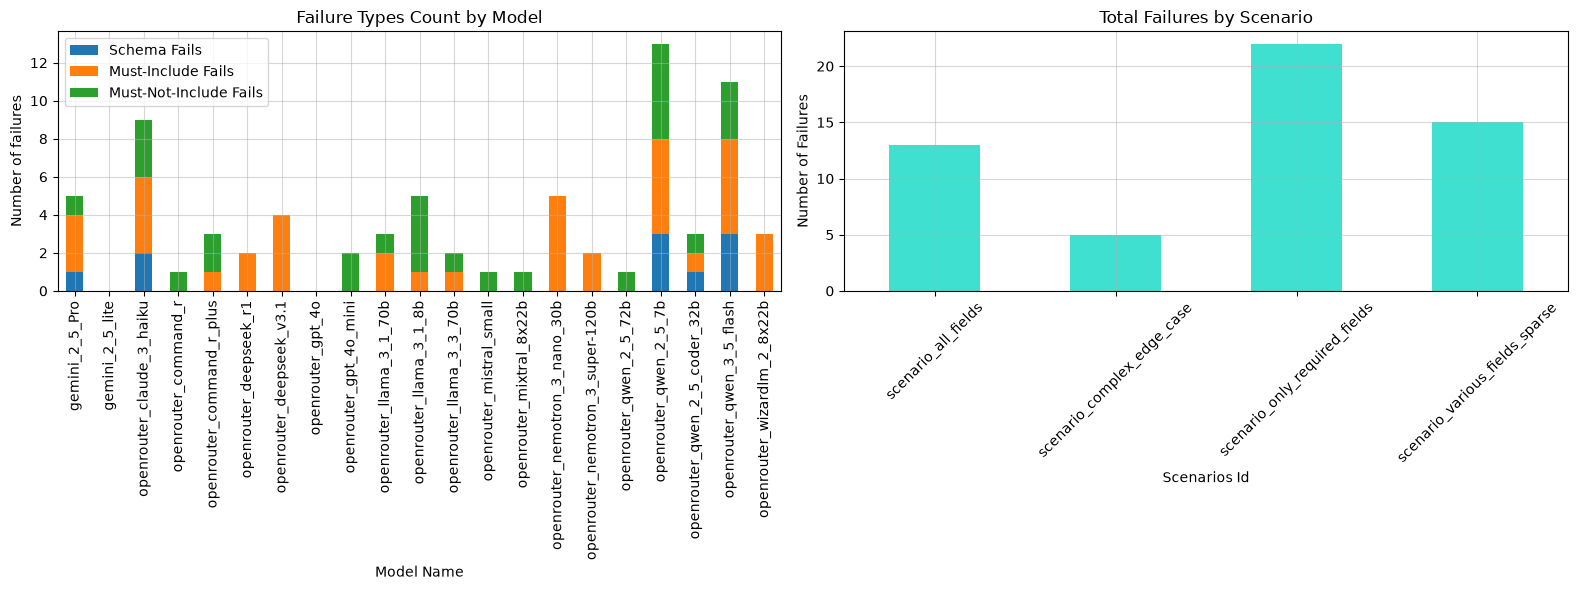

In [4]:
_, (ax1, ax2) = plt.subplots (1, 2, figsize = (16, 6))
model_failures.plot(
    kind = 'bar',
    stacked = True,
    ax = ax1,
)

ax1.set_title('Failure Types Count by Model')
ax1.set_ylabel('Number of failures')
ax1.set_xlabel('Model Name')
ax1.legend(['Schema Fails', 'Must-Include Fails', 'Must-Not-Include Fails'])

scenario_failures = df.groupby('scenario_id')['passed'].apply(
    lambda x: (x == False).sum()
)
scenario_failures.plot (kind = 'bar', color = 'turquoise', ax = ax2)
ax2.set_title ('Total Failures by Scenario')
ax2.set_ylabel('Number of Failures')
ax2.set_xlabel('Scenarios Id')
ax2.tick_params(axis = 'x', rotation = 45)

ax1.grid(True, alpha = 0.5), ax2.grid(True, alpha = 0.5)
plt.tight_layout()
plt.show()

# Analysis
---
Failed Test Types
* 1st: gpt4o, gemini 2.5 flash lite passes all cases
* mistral_small, qwen 2.5 72b, mixtral 8x22b, command r: Failed 1 must-not include testcase
* gpt4o-mini: fail 2 must-not-include testcases

=> Cheap models with low temperature seems to meet the requirements better.

---
Types of testcases:
* Complexede Cases: only 5 fails
* All Fields: 13 fails
* Required Fields only: 21 fails
* Various fields sparse: 15 fails

=> The hard thing for the model is to maintain the structure of the draft.

---

# Document the token usage and estimated cost

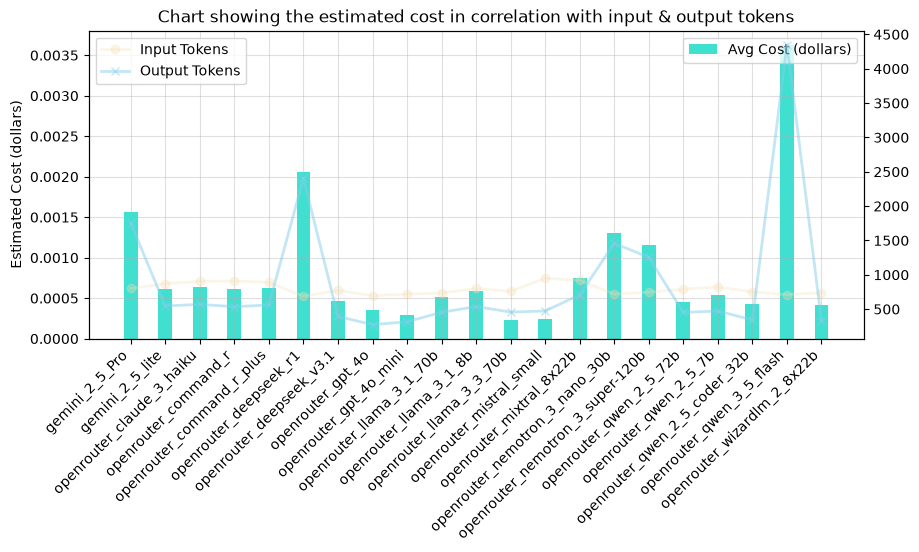

In [11]:
model_stats = df.groupby ('model_name')[[
    'estimated_cost',
    'input_tokens',
    'output_tokens',
]].mean().reset_index()

_, ax1 = plt.subplots (figsize = (10, 4))

x_indices = np.arange (len (model_stats['model_name']))
bar_width = 0.4
cost_bars = ax1.bar (
    x_indices,
    model_stats['estimated_cost'],
    width = bar_width,
    label = 'Avg Cost (dollars)',
    color = 'turquoise',
)
ax1.set_ylabel('Estimated Cost (dollars)')
ax1.set_xticks(x_indices)
ax1.set_xticklabels(model_stats['model_name'], rotation = 45, ha = 'right')

ax2 = ax1.twinx()
line_input = ax2.plot(
    x_indices,
    model_stats['input_tokens'],
    label = 'Input Tokens',
    marker = 'o',
    color = 'wheat',
    linewidth  = 2,
    alpha = 0.3,
)
line_output = ax2.plot(
    x_indices,
    model_stats['output_tokens'],
    label = 'Output Tokens',
    marker = 'x',
    linewidth = 2,
    color = 'skyblue',
    alpha = 0.5,
)

ax1.grid(True, alpha = 0.4)
ax1.set_title ('Chart showing the estimated cost in correlation with input & output tokens')
ax1.legend(loc = 'upper right')
ax2.legend(loc = 'upper left')

# Analysis:
---
* 1/ llama_3.3_70b: lowest estimated cost & output tokens
* 2/ mistral small: also lowest estimated cost & decent output_tokens
* 4/ gpt 4o mini: low estimated cost & low output token
* 5-7/ qwen 2.5 72b & qwern 2.5 coder 42b & wizardlm
* 8/ deepseek v3.1 & llama 3.1 70b
* 9-10/ gemini 2.5 lite & llama 3.1 8b

---

# Latency Evaluation

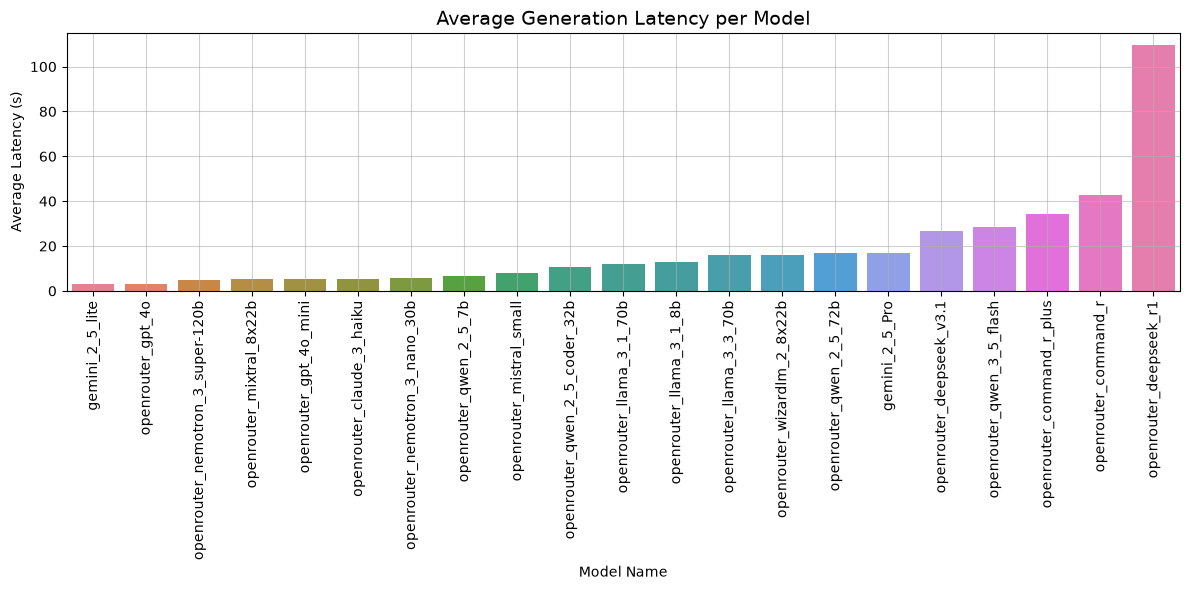

In [25]:
avg_latency = df.groupby ('model_name')['latency_seconds'].mean().reset_index().sort_values(by = 'latency_seconds')
plt.figure (figsize = (12, 6))
sns.barplot(
    data = avg_latency,
    x = 'model_name',
    y = 'latency_seconds',
    hue = 'model_name',
    legend = False,
)
plt.title ('Average Generation Latency per Model', fontsize = 14)
plt.xlabel ('Model Name')
plt.ylabel ('Average Latency (s)')
plt.tick_params (axis = 'x', rotation = 90)
plt.grid(True, alpha = 0.6)
plt.tight_layout()
plt.show()

# Quality Score

In [ ]:
score_cols = [
    'specificity_score',
    'tone_score',
    'faithfullness_score',
    'linkedin_readiness_score',
    'refinement_quality_score',
    'overall_quality_score',
]

avg_scores = df.groupby('model_name')[score_cols].mean().reset_index()

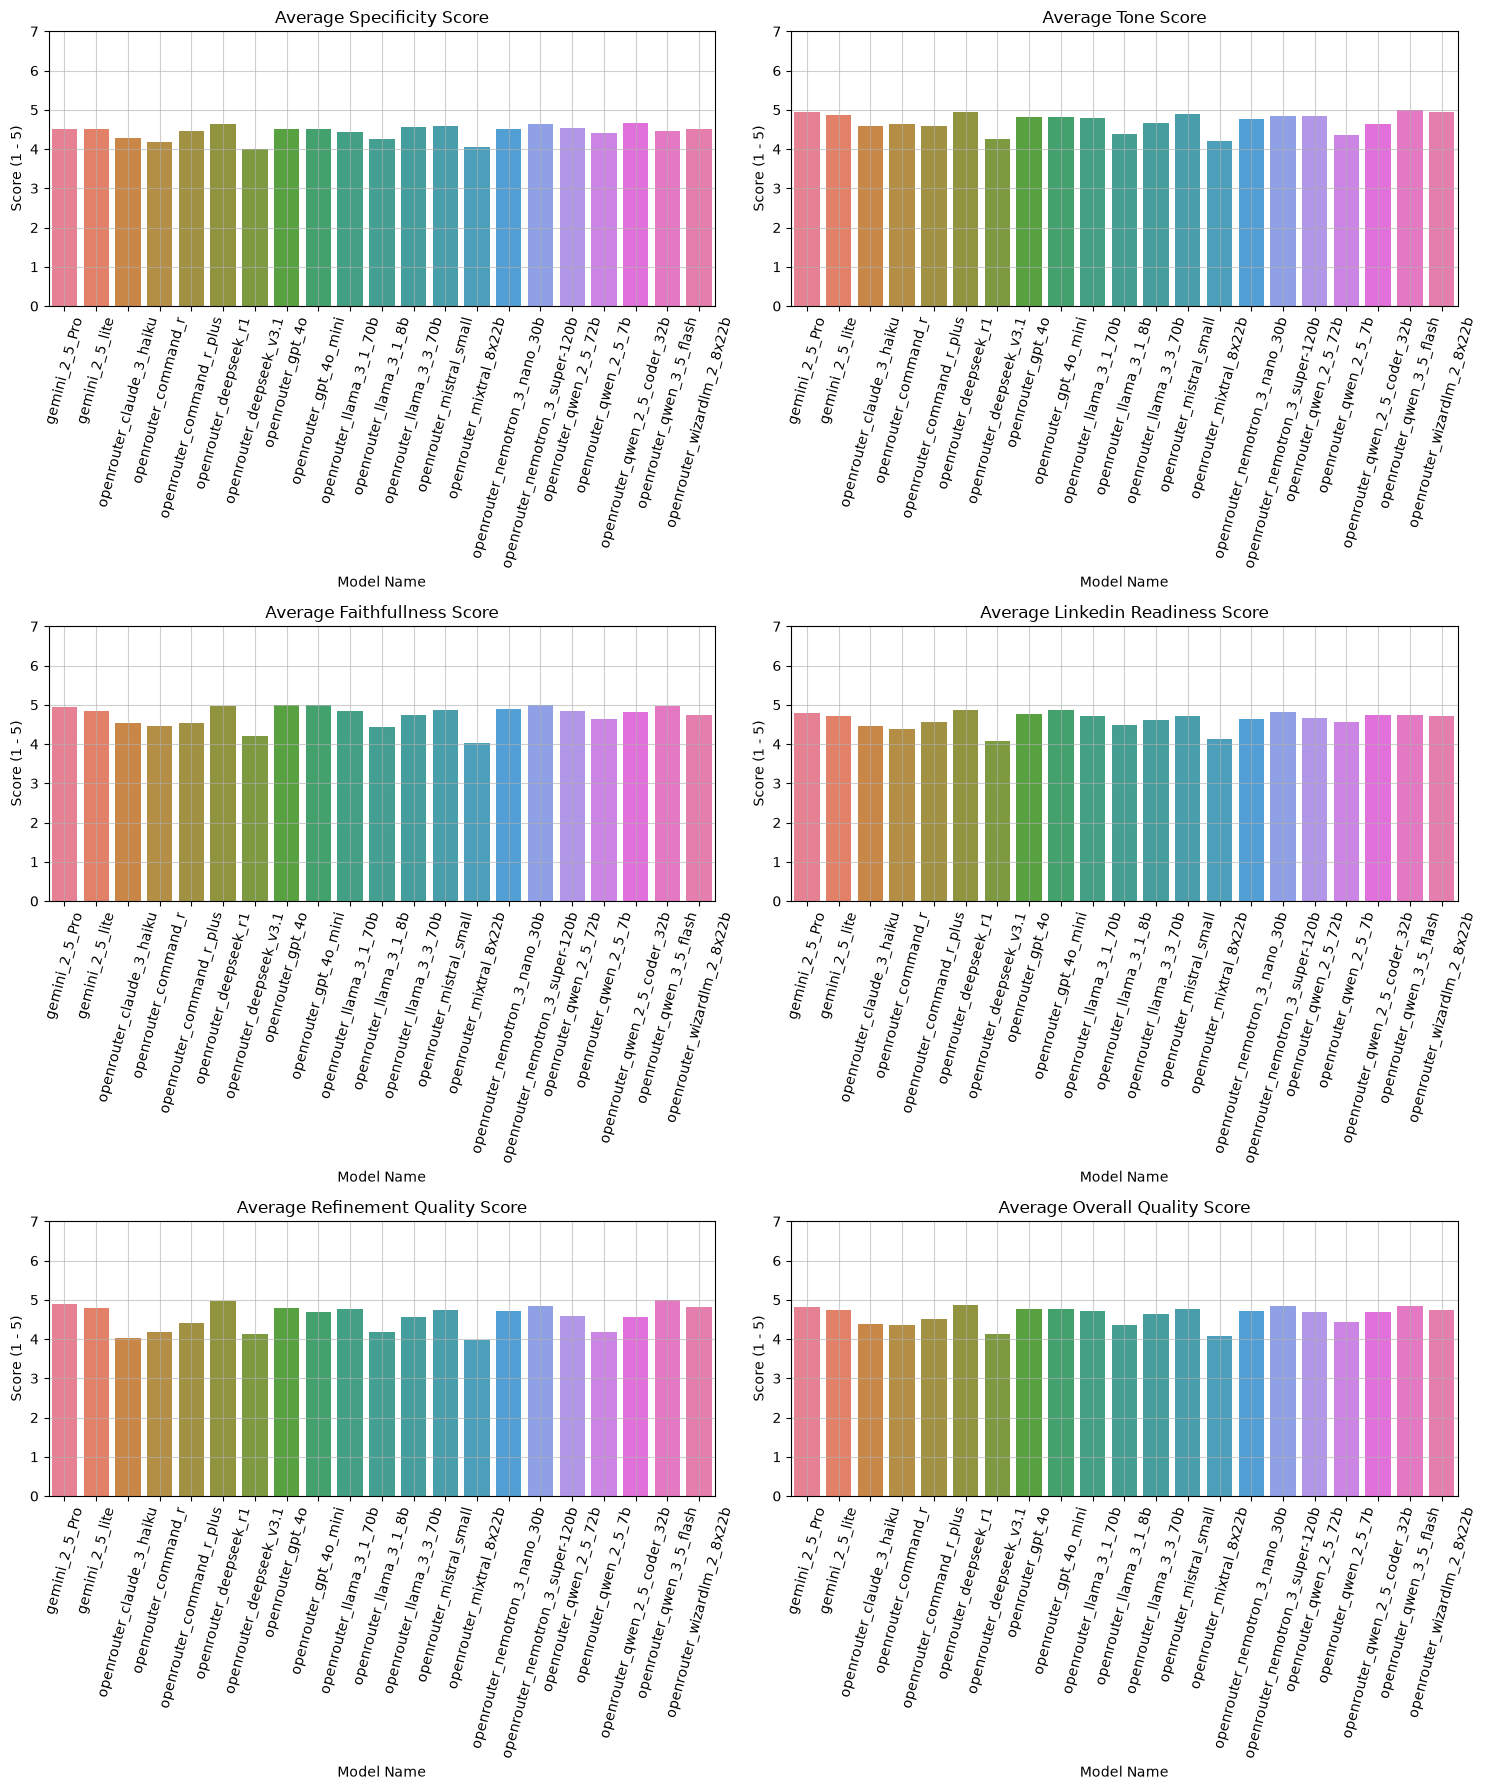

In [ ]:
_, axes = plt.subplots(3, 2, figsize = (15, 18))
axes = axes.flatten()
for i, col in enumerate(score_cols):
    sns.barplot(
        data = avg_scores,
        hue = 'model_name',
        x = 'model_name',
        y = col,
        ax = axes[i],
        legend = False,
    )
    axes[i].set_title (f'Average {col.replace ('_', ' ').title()}', fontsize = 12)
    axes[i].set_xlabel ("Model Name", fontsize = 10)
    axes[i].set_ylabel ("Score (1 - 5)", fontsize = 10)
    axes[i].set_ylim (0, 7.0)
    axes[i].tick_params(axis = 'x', rotation = 75)
    axes[i].grid(True, alpha = 0.6)

plt.tight_layout()
plt.show()